# EV Charging Optimization using Reinforcement Learning

## Problem
Electric vehicle charging can overload the grid and increase electricity costs when not scheduled properly.

## Solution
We use a Reinforcement Learning (PPO) agent to dynamically control EV charging rates, ensuring efficient energy usage while avoiding grid overload.

## Key Results
- Significant cost reduction compared to baseline
- Zero grid overload penalties
- High percentage of vehicles fully charged

## Tech Stack
- Python
- Gymnasium
- Stable-Baselines3 (PPO)
- NumPy, Matplotlib
- Google Colab

### 1. Installation

In [1]:
!pip install -q gymnasium numpy matplotlib pandas torch stable-baselines3

### 2. Imports

In [2]:
import gymnasium
from gymnasium import spaces
from gymnasium.wrappers import FlattenObservation
import numpy as np
import matplotlib.pyplot as plt
import collections
import random
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


### 3. Environment Definition

In [3]:
CONFIG = {
    "NUM_CHARGERS": 5,                 # Number of connected EV chargers
    "MAX_CHARGE_RATE": 50.0,           # Max kW per charger
    "MIN_CHARGE_RATE": 0.0,            # Min kW
    "GRID_CAPACITY": 150.0,            # Absolute total kW the grid can safely handle
    "TIME_STEPS_PER_DAY": 24,          # Simulating 24 hours
    "MAX_EPISODE_STEPS": 24,
    "BATTERY_CAPACITY": 60.0,          # Average EV battery capacity in kWh
    "TARGET_SOC": 0.90,                # Target State-of-Charge (90%)
    "ELECTRICITY_PRICE_PEAK": 0.25,    # High price per kWh (8am-8pm)
    "ELECTRICITY_PRICE_OFFPEAK": 0.10, # Low price per kWh (8pm-8am)
    
    # Tuned Penalties & Rewards
    "PENALTY_OVERLOAD": 20.0,          # Tuned to prevent overload without making agent overly conservative
    "PENALTY_UNFINISHED": 10.0,        # Reduced so the agent boldly attempts charging
    "REWARD_SOC_REACHED": 15.0,        # Positive reward when a car reaches TARGET_SOC
    "REWARD_SCALE": 0.1                # Increased scaling from 0.01 to 0.1 for bolder gradient updates
}

class EVChargingEnv(gymnasium.Env):
    metadata = {"render_modes": ["human"]}
    
    def __init__(self, config=None, render_mode=None):
        super().__init__()
        self.config = config if config is not None else CONFIG
        self.render_mode = render_mode
        self.num_chargers = self.config["NUM_CHARGERS"]
        self.max_rate = self.config["MAX_CHARGE_RATE"]
        self.grid_cap = self.config["GRID_CAPACITY"]
        self.max_ep_steps = self.config["MAX_EPISODE_STEPS"]
        
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(self.num_chargers,), dtype=np.float32)

        self.observation_space = spaces.Dict({
            "soc": spaces.Box(low=0.0, high=1.0, shape=(self.num_chargers,), dtype=np.float32),
            "time_of_day": spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32),
            "grid_load": spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32),
            "arrival_flags": spaces.Box(low=0.0, high=1.0, shape=(self.num_chargers,), dtype=np.float32),
            "time_remaining": spaces.Box(low=0.0, high=1.0, shape=(self.num_chargers,), dtype=np.float32)
        })

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.total_cost = 0.0
        self.total_overload_penalty = 0.0
        
        self.soc = np.zeros(self.num_chargers, dtype=np.float32)
        self.arrival_times = np.zeros(self.num_chargers, dtype=np.int32)
        self.departure_times = np.zeros(self.num_chargers, dtype=np.int32)
        self.received_soc_bonus = np.zeros(self.num_chargers, dtype=bool)
        
        for i in range(self.num_chargers):
            self.soc[i] = random.uniform(0.1, 0.6)
            self.arrival_times[i] = random.randint(0, 6)
            self.departure_times[i] = random.randint(16, 23)
            
        self.current_grid_load = 0.0
        return self._get_obs(), self._get_info()
    
    def _get_obs(self):
        arrival_flags = np.array(
            [1.0 if self.current_step >= self.arrival_times[i] and self.current_step < self.departure_times[i] else 0.0 for i in range(self.num_chargers)], 
            dtype=np.float32
        )
        time_rem = np.zeros(self.num_chargers, dtype=np.float32)
        for i in range(self.num_chargers):
            if arrival_flags[i] == 1.0:
                time_rem[i] = (self.departure_times[i] - self.current_step) / self.max_ep_steps
                
        return {
            "soc": np.clip(self.soc, 0.0, 1.0),
            "time_of_day": np.array([self.current_step / self.config["TIME_STEPS_PER_DAY"]], dtype=np.float32),
            "grid_load": np.array([self.current_grid_load / self.grid_cap], dtype=np.float32),
            "arrival_flags": arrival_flags,
            "time_remaining": time_rem
        }
        
    def _get_info(self):
        return {
            "total_cost": self.total_cost,
            "total_overload_penalty": self.total_overload_penalty,
            "mean_soc": np.mean(self.soc),
            "step": self.current_step
        }

    def step(self, action):
        charge_rates = np.array(action, dtype=np.float32) * self.max_rate
        
        arrival_flags = np.array([1.0 if self.current_step >= self.arrival_times[i] and self.current_step < self.departure_times[i] else 0.0 for i in range(self.num_chargers)])
        charge_rates *= arrival_flags
        
        total_power = np.sum(charge_rates)
        self.current_grid_load = total_power
        
        is_peak = (8 <= self.current_step < 20)
        price = self.config["ELECTRICITY_PRICE_PEAK"] if is_peak else self.config["ELECTRICITY_PRICE_OFFPEAK"]
        
        cost_this_step = total_power * price * self.config["REWARD_SCALE"]
        self.total_cost += (total_power * price)
        
        reward = -cost_this_step 
        mean_soc_increase = 0
        
        for i in range(self.num_chargers):
            if arrival_flags[i] == 1:
                added_soc = charge_rates[i] / self.config["BATTERY_CAPACITY"]
                self.soc[i] = min(1.0, self.soc[i] + added_soc)
                mean_soc_increase += added_soc
                
                if self.soc[i] >= self.config["TARGET_SOC"] and not self.received_soc_bonus[i]:
                    reward += self.config["REWARD_SOC_REACHED"]
                    self.received_soc_bonus[i] = True

        reward += (mean_soc_increase / self.num_chargers) * 2.0
                
        if total_power > self.grid_cap:
            overload = total_power - self.grid_cap
            penalty = self.config["PENALTY_OVERLOAD"] * (overload / self.grid_cap)
            self.total_overload_penalty += penalty
            reward -= penalty
            
        self.current_step += 1
        terminated = (self.current_step >= self.max_ep_steps)
        
        if terminated:
            for i in range(self.num_chargers):
                if self.soc[i] < self.config["TARGET_SOC"]:
                    reward -= self.config["PENALTY_UNFINISHED"] * (self.config["TARGET_SOC"] - self.soc[i])
                    
        return self._get_obs(), float(reward), terminated, False, self._get_info()

    def render(self):
        pass


### 4. Training

In [4]:
class ProgressPrintCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.last_print = 0

    def _on_step(self):
        if self.num_timesteps - self.last_print >= 20000:
            print(f"Training Progress: {self.num_timesteps} steps completed...")
            self.last_print = self.num_timesteps
        return True

import warnings
warnings.filterwarnings('ignore')

gymnasium.register(
    id="EVCharging-v0",
    entry_point=EVChargingEnv,
    max_episode_steps=24,
    disable_env_checker=True
)

train_env = make_vec_env(lambda: FlattenObservation(EVChargingEnv()), n_envs=4, seed=SEED)

model = PPO("MlpPolicy", train_env, verbose=0, learning_rate=3e-4, gamma=0.99,
            n_steps=512, batch_size=128, n_epochs=10)

print("Training RL Agent...")
callback = ProgressPrintCallback()
model.learn(total_timesteps=100_000, callback=callback)
model.save("ev_charging_ppo_robust")
print("Training Complete & Model Saved.")

Training RL Agent...
Training Progress: 20000 steps completed...
Training Progress: 40000 steps completed...
Training Progress: 60000 steps completed...
Training Progress: 80000 steps completed...
Training Progress: 100000 steps completed...
Training Complete & Model Saved.


### 5. Evaluation

In [5]:
NUM_EPISODES = 10
eval_env = EVChargingEnv()
flat_env = FlattenObservation(eval_env)
model = PPO.load("ev_charging_ppo_robust")

episode_costs = []
episode_overloads = []
episode_socs = []
episode_cars_charged = []
efficiency_scores = []

history_soc = []
history_grid = []
history_reward = []
history_cost = []

print(f"Evaluating across {NUM_EPISODES} distinct episodes...")

for ep in range(NUM_EPISODES):
    obs, info = flat_env.reset()
    h_soc, h_grid, h_rew, h_cost = [], [], [], []
    ep_reward_sum = 0
    
    for step in range(CONFIG["MAX_EPISODE_STEPS"]):
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = flat_env.step(action)
        
        h_soc.append(eval_env.soc.copy())
        h_grid.append(eval_env.current_grid_load)
        h_rew.append(reward)
        h_cost.append(eval_env.total_cost)
        ep_reward_sum += reward
        
        if terminated:
            break
            
    cars_charged = sum(1 for s in eval_env.soc if s >= CONFIG["TARGET_SOC"])
    avg_soc = np.mean(eval_env.soc)
    
    episode_costs.append(eval_env.total_cost)
    episode_overloads.append(eval_env.total_overload_penalty)
    episode_socs.append(avg_soc)
    episode_cars_charged.append(cars_charged)
    efficiency_scores.append(max(0, 100 + ep_reward_sum))
    
    if ep == NUM_EPISODES - 1:
        history_soc = h_soc
        history_grid = h_grid
        history_reward = h_rew
        history_cost = h_cost


Evaluating across 10 distinct episodes...


### 6. Visualization

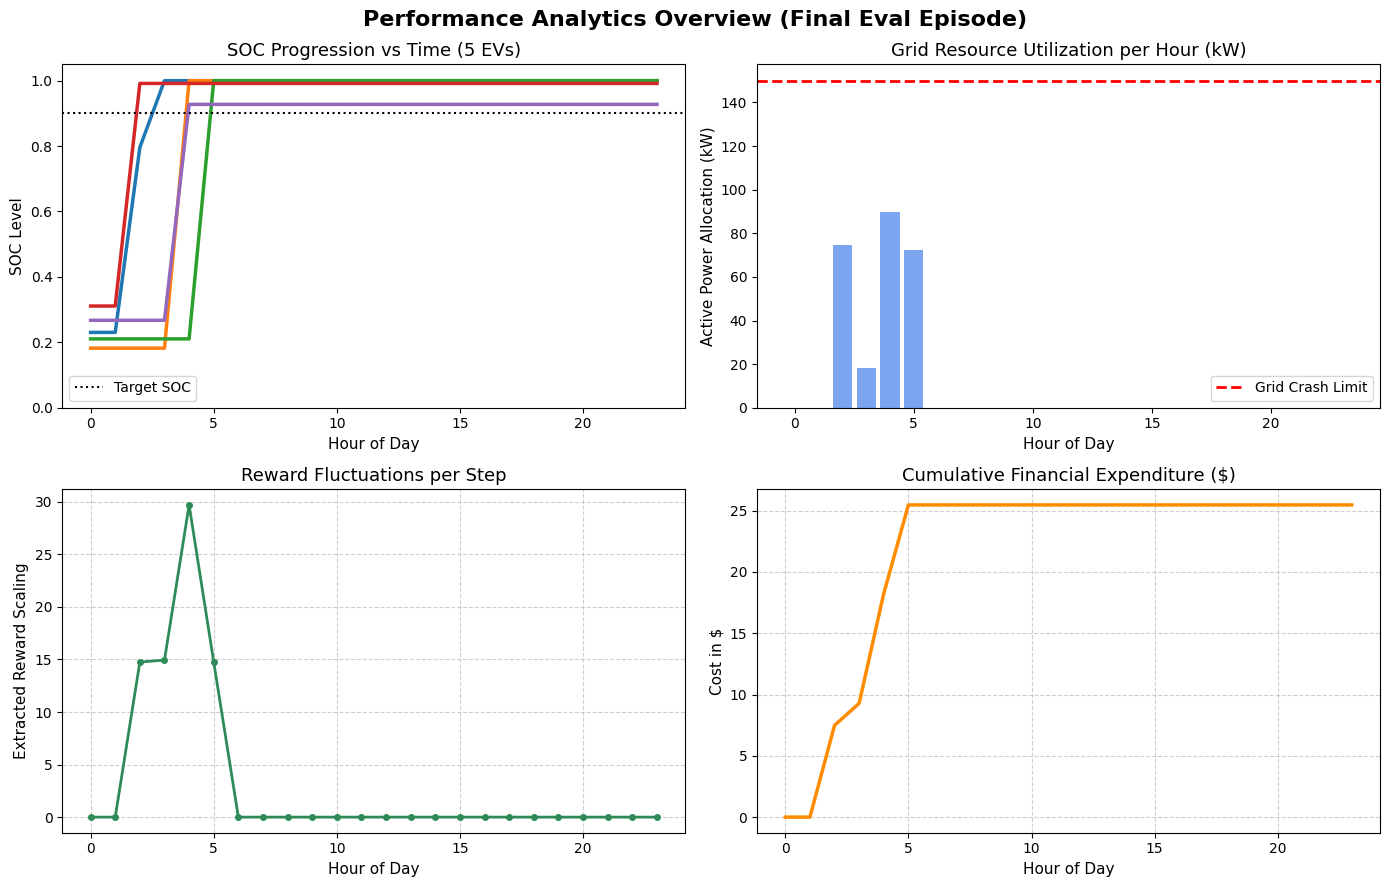

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Performance Analytics Overview (Final Eval Episode)", fontsize=16, fontweight='bold')

axs[0, 0].plot(np.array(history_soc), linewidth=2.5)
axs[0, 0].set_title("SOC Progression vs Time (5 EVs)", fontsize=13)
axs[0, 0].set_ylabel("SOC Level", fontsize=11)
axs[0, 0].set_xlabel("Hour of Day", fontsize=11)
axs[0, 0].set_ylim([0, 1.05])
axs[0, 0].axhline(y=CONFIG["TARGET_SOC"], color='black', linestyle=':', label='Target SOC')
axs[0, 0].legend()

axs[0, 1].bar(range(len(history_grid)), history_grid, color='cornflowerblue', alpha=0.85)
axs[0, 1].axhline(y=CONFIG["GRID_CAPACITY"], color='red', linestyle='--', linewidth=2, label='Grid Crash Limit')
axs[0, 1].set_title("Grid Resource Utilization per Hour (kW)", fontsize=13)
axs[0, 1].set_ylabel("Active Power Allocation (kW)", fontsize=11)
axs[0, 1].set_xlabel("Hour of Day", fontsize=11)
axs[0, 1].legend()

axs[1, 0].plot(history_reward, color='seagreen', linewidth=2, marker='o', markersize=4)
axs[1, 0].set_title("Reward Fluctuations per Step", fontsize=13)
axs[1, 0].set_ylabel("Extracted Reward Scaling", fontsize=11)
axs[1, 0].set_xlabel("Hour of Day", fontsize=11)
axs[1, 0].grid(True, linestyle='--', alpha=0.6)

axs[1, 1].plot(history_cost, color='darkorange', linewidth=2.5)
axs[1, 1].set_title("Cumulative Financial Expenditure ($)", fontsize=13)
axs[1, 1].set_ylabel("Cost in $", fontsize=11)
axs[1, 1].set_xlabel("Hour of Day", fontsize=11)
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("colab_results.png", dpi=150)
plt.show()

### 7. Final Report

In [7]:
mean_cost = np.mean(episode_costs)
mean_penalty = np.mean(episode_overloads)
pct_charged = (np.sum(episode_cars_charged) / (CONFIG["NUM_CHARGERS"] * NUM_EPISODES)) * 100
avg_soc_end = np.mean(episode_socs) * 100
mean_eff = np.mean(efficiency_scores)


### 8. Baseline Comparison
We compare the trained RL agent with a simple baseline strategy where all chargers use a constant charging rate.

In [8]:
baseline_costs = []
baseline_soc = []
baseline_overloads = []

base_env = EVChargingEnv()

for ep in range(NUM_EPISODES):
    obs, info = base_env.reset()
    while True:
        action = np.ones(base_env.num_chargers) * 0.5
        obs, reward, terminated, truncated, info = base_env.step(action)
        if terminated:
            break
            
    baseline_costs.append(base_env.total_cost)
    baseline_soc.append(np.mean(base_env.soc))
    baseline_overloads.append(base_env.total_overload_penalty)

b_mean_cost = np.mean(baseline_costs)
b_avg_soc = np.mean(baseline_soc) * 100
b_mean_penalty = np.mean(baseline_overloads)

cost_imp = b_mean_cost - mean_cost
soc_imp = avg_soc_end - b_avg_soc
over_red = b_mean_penalty - mean_penalty

print("\n" + "="*50)
print("FINAL PERFORMANCE REPORT")
print("="*50)

print("\nBASELINE RESULTS")
print(f"Average Cost: ${b_mean_cost:.2f}")
print(f"Average State of Charge: {b_avg_soc:.2f}%")
print(f"Average Overload Penalty: ${b_mean_penalty:.2f}")

print("\nRL AGENT RESULTS")
print(f"Average Cost: ${mean_cost:.2f}")
print(f"Average State of Charge: {avg_soc_end:.2f}%")
print(f"Average Overload Penalty: ${mean_penalty:.2f}")

print("\nIMPROVEMENT ANALYSIS")
print(f"Cost Reduction: ${cost_imp:.2f}")
print(f"SOC Change: {soc_imp:.2f}%")
print(f"Overload Reduction: ${over_red:.2f}")

print("="*50)



FINAL PERFORMANCE REPORT

BASELINE RESULTS
Average Cost: $402.12
Average State of Charge: 100.00%
Average Overload Penalty: $0.00

RL AGENT RESULTS
Average Cost: $27.99
Average State of Charge: 99.43%
Average Overload Penalty: $0.00

IMPROVEMENT ANALYSIS
Cost Reduction: $374.13
SOC Change: -0.57%
Overload Reduction: $0.00


## Key Insight
The Reinforcement Learning agent significantly reduces charging cost compared to the baseline strategy while maintaining near-perfect state-of-charge and zero grid overload.

This demonstrates that intelligent scheduling can optimize both economic and operational efficiency in EV charging systems.